<div style="text-align: center; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 24px;">
    <h1>
        SINAIS E SISTEMAS EM TEMPO CONTÍNUO: RESPOSTA EM FREQUÊNCIA E FILTROS
    </h1>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <p>
    <h2>
        Introdução
    </h2>
    <p style="text-indent: 2em;">
        A caracterização de sinais e sistemas no domínio de Laplace e de Fourier demonstrou ser extremamente útil nos notebooks anteriores. Através dela, torna-se praticável a análise de sistemas grandes, complexos, mas ainda lineares, de tal forma que podem ser decompostos em subsistemas mais simples. O assunto final do nosso estudo de relações entrada-saída de sistemas LCIT, será a montagem e descrição de sistemas interconectados, sob a ótica do regimes da frequência, que naturalmente induz o conceito de filtragem.
</div>

$$
\frac{Y(S)}{X(S)} = \frac{W(S)}{X(S)}\frac{Y(S)}{W(S)}=H_1(S)H_2(S)
$$

<div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
    Conexão em cascata de funções de transferência.
</div>

<div style="
    font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif;
    font-size: 20px;
">

<h2>Sumário</h2>

<div style="
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 40px;
    align-items: start;
">
    <div>
        <h4>1 - Realização de Sistemas</h4>
        <ul>
            <li>1.1 - Forma Direta I</li>
            <li>1.2 - Forma Direta II</li>
            <li>1.3 - Realização em Cascata e Paralelo</li>
            <li>1.4 - Realização Transposta</li>
            <li>1.5 - Diagramas de Blocos no Python</li>
        </ul>
        <h4>2 - Resposta em Frequência</h4>
        <ul>
            <li>2.1 - Diagramas de Bode</li>
            <li>2.2 - Sistemas de Primeira Ordem</li>
            <li>2.3 - Sistemas de Segunda Ordem</li>
        </ul>
    </div>
    <div>
        <h4>3 - Filtros</h4>
        <ul>
            <li>3.1 - Passa Baixas</li>
            <li>3.2 - Passa Faixa</li>
            <li>3.3 - Rejeita Faixa</li>
            <li>3.4 - Filtros Práticos</li>
            <li>3.5 - Filtros de Butterworth</li>
        </ul>
        <h4>4 - Algo Computacional</h4>
        <ul>
            <li>4.1 - Como Utilizar a Função</li>
            <li>4.2 - Exemplo</li>
        </ul>
    </div>
</div>
</div>


<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        1 - Realização de Sistemas
    </h2>
    <p style="text-indent: 2em;">
    Por meio de diagramas de blocos, iremos representar sistemas lineares interconectados. Tipicamente, tais blocos representam funções de transferência que atuam sobre um sinal de entrada. Nesse contexto, as três principais formas de conectar sistemas sâo: em cascata, em paralelo e em retroalimentação. É possível demonstrar que essas conexões podem ser combinadas conforme a figura abaixo, de maneira remetente à circuitos equivalentes de Thévenin.
</div>
<center>
<img src="imagens\conexoes.png" width="500" height="500" alt="conexões" >
</center>
<div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
        Fonte: 'Linear Signals and Systems - 3 ed. - B.P. Lathi'
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    Nas subseções à frente, serão estudadas formas de implementar a função de transferência racional, geral, oriunda de sistemas diferenciais lineares.
</div>

$$
H(s) = \frac{b_0 s^N+b_1s^{N-1}+ \dots +b_{N-1}s+b_N}{s^N+a_1S^{N-1}+\dots+a_{N-1}s+a_N}
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.1 - Forma Direta I
    </h4>
    <p style="text-indent: 2em;">
        A decomposição da função de transferência em um produto entre o numerador e o denominador, induz uma representação em cascata de entre H<sub>1</sub> e H<sub>2</sub>:
</div>

$$
H(s) = \left (b_0 + \frac{b_1}{s} + \frac{b_2}{s^2} + \dots + \frac{b_N}{s^N} \right )
       \left (\frac{1}{1 + \frac{a_1}{s}+ \frac{a_2}{s^2} + \dots + \frac{a_N}{s^N}} \right ) = H_1(s)H_2(s).
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
        Na forma direta I, cada termo no produto é montado usando somadores e integradores (1/s), com a saída do sistema H<sub>1</sub> (numerador) alimentando a entrada de H<sub>2</sub> (denominador). Esse procedimento requer 2N blocos integradores para realizar uma EDO de ordem N.
        <center><img src="imagens\forma direta I.png" width="500" height="400" alt="direta 1" ></center>
        <div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
        Fonte: 'Linear Signals and Systems - 3 ed. - B.P. Lathi'
</div>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    NOTA: Integradores, tanto matematicamente quanto fisicamente em implementações reais, tendem a suavizar sinais, eliminando ruído. Em contraposição, diferenciadores geralmente amplificam componentes de altas frequências, resultando em saídas ruidosas e instabilidade. Portanto, há na maioria dos casos, uma preferência a favor dos blocos integradores.
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.2 - Forma Direta II
    </h4>
    <p style="text-indent: 2em;">
        Como a cascata de funções de transferência é comutativa, é possível implementar o sistema H<sub>2</sub> alimentando o sistema H<sub>1</sub>. Interessantemente, surge uma redundância no uso dos blocos integradores: a saída das duas cadeias de integradores são equivalentes, então uma delas pode ser eliminada sem afetar a funcionalidade do diagrama de blocos. A realização de uma EDO de grau N (com polinômio diferencial das entradas também de grau N) requer no mínimo N integradores. Dizemos que uma realização é <i>canônica</i>, se ela utiliza o número mínimo desses blocos. Por isso, a forma direta II é também conhecida como <i>forma canônica direta</i>.
    <center><img src="imagens\forma direta II.png" width="400" height="400" alt="canonica" ></center>
    <center><img src="imagens\forma direta I.png" width="500" height="400" alt="direta 1" ></center>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.3 - Realização em Cacata e Paralelo
    </h4>
    <p style="text-indent: 2em;">
        Fatorando o polinômio de s no denominador em termo de seus polos, uma função de transferência H(s) de ordem N é separável no produto (cascata), ou na soma (paralelo) de frações parciais, de até N termos. Ou seja, um sistema de ordem superior pode ser decomposto em subsistemas de ordem inferior. Quando os polos são reais, esses subsistemas podem ser todos de primeira ordem, mas quando surgem polos complexos conjugados, é preciso manter sistema(s) de ordem 2, pois a álgebra de números complexos não é factível em sistemas reais! Infelizmente, não existe corrente elétrica imaginária na vida real.
    <center><img src="imagens\eq de schroedinger.png" width="600" height="300" alt="John Ponderando" ></center>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.4 - Realização Transposta
    </h4>
    <p style="text-indent: 2em;">
        Conforme foi visto até então, a síntese de uma função de transferência pode ser feita de diversas maneiras e dizemos que duas realizações são <i>equivalentes</i> quando produzem a mesma H(s). Uma maneira de obter uma realização equivalente a partir de um dado diagrama de blocos, é com a realização <i>transposta</i> correspondente. Para obtê-la deevemos:
    <ol>
        <li>Inverter o sentido de todas as direções</li>
        <li>Trocar nós de derivação por somadores e somadores por nós dee derivação</li>
        <li>Trocar X(s) por Y(s) e vice versa</li>
    </ol>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.5 - Diagramas de Blocos no Python
    </h4>
    <p style="text-indent: 2em;">
        A biblioteca <a href="https://view.pathsim.org/">'Pathsim'</a> oferece uma forma fácil de mexer com diagramas de blocos computacionalmente. Ela é aberta e possui uma interface interativa, dispensando até a necessidade de escrever código para montar um sistema. Abaixo, um exemplo de um sistema de terceira ordem na forma canônica direta:
    <center><img src="imagens\pathsim.png" width="800" height="600" alt="pathsim" ></center>
</div>

20:02:50 - INFO - LOGGING (log: True)
20:02:50 - INFO - BLOCKS (total: 17, dynamic: 3, static: 14, eventful: 0)
20:02:50 - INFO - GRAPH (nodes: 17, edges: 22, alg. depth: 6, loop depth: 0, runtime: 0.070ms)
20:02:50 - INFO - STARTING -> TRANSIENT (Duration: 10.00s)
20:02:50 - INFO - --------------------   1% | 0.0s<0.1s | 8263.4 it/s
20:02:50 - INFO - ####----------------  20% | 0.0s<0.1s | 6448.5 it/s
20:02:50 - INFO - ########------------  40% | 0.1s<0.1s | 7749.5 it/s
20:02:50 - INFO - ############--------  60% | 0.1s<0.1s | 7651.8 it/s
20:02:50 - INFO - ################----  80% | 0.1s<0.0s | 7395.0 it/s
20:02:50 - INFO - #################### 100% | 0.1s<--:-- | 7458.5 it/s
20:02:50 - INFO - FINISHED -> TRANSIENT (total steps: 1001, successful: 1001, runtime: 140.43 ms)


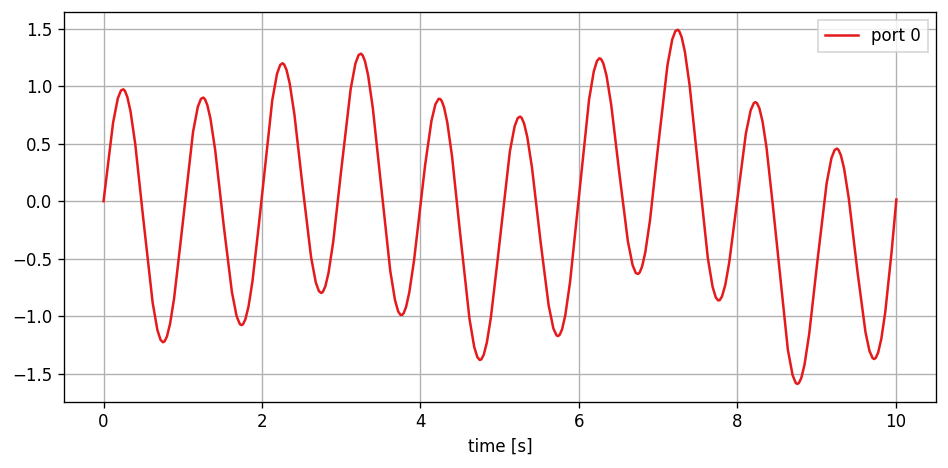

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PathSim Simulation
==================
Generated by PathView on 2026-05-19 01:23:54
https://view.pathsim.org
PathSim documentation: https://docs.pathsim.org
"""
import numpy as np
import matplotlib.pyplot as plt
from pathsim import Simulation, Connection
from pathsim.blocks import ( Adder, Amplifier, Integrator, Scope, SinusoidalSource)
from pathsim.solvers import SSPRK22
# ────────────────────────────────────────────────────────────────────────────
# BLOCKS
# ────────────────────────────────────────────────────────────────────────────
# Sources
sinusoidalsource = SinusoidalSource()
# Dynamic
integrator = Integrator()
block_2 = Integrator()
block_3 = Integrator()
# Algebraic
adder = Adder()
block_5 = Adder()
block_6 = Adder()
block_7 = Adder()
block_8 = Adder()
block_9 = Adder()
amplifier = Amplifier(gain=-1)
block_11 = Amplifier()
block_12 = Amplifier(gain=-2)
block_13 = Amplifier(gain=0)
block_14 = Amplifier(gain=-3)
block_15 = Amplifier(gain=2)
# Recording
scope = Scope()
blocks = [
    sinusoidalsource, integrator, block_2, block_3, adder, block_5, block_6, block_7, block_8,
    block_9, amplifier, block_11, block_12, block_13, block_14, block_15, scope,
]
# ────────────────────────────────────────────────────────────────────────────
# CONNECTIONS
# ────────────────────────────────────────────────────────────────────────────
conn_0 = Connection(adder[0], block_7[0])
conn_1 = Connection(adder[0], integrator[0])
conn_2 = Connection(integrator[0], block_2[0])
conn_3 = Connection(block_2[0], block_3[0])
conn_4 = Connection(sinusoidalsource[0], adder[0])
conn_5 = Connection(block_6[0], block_5[1])
conn_6 = Connection(block_9[0], block_8[1])
conn_7 = Connection(block_5[0], adder[1])
conn_8 = Connection(block_8[0], block_7[1])
conn_9 = Connection(block_7[0], scope[0])
conn_10 = Connection(integrator[0], amplifier[0])
conn_11 = Connection(amplifier[0], block_5[0])
conn_12 = Connection(integrator[0], block_11[0])
conn_13 = Connection(block_11[0], block_8[0])
conn_14 = Connection(block_2[0], block_12[0])
conn_15 = Connection(block_12[0], block_6[0])
conn_16 = Connection(block_2[0], block_13[0])
conn_17 = Connection(block_13[0], block_9[0])
conn_18 = Connection(block_3[0], block_14[0])
conn_19 = Connection(block_14[0], block_6[1])
conn_20 = Connection(block_3[0], block_15[0])
conn_21 = Connection(block_15[0], block_9[1])

connections = [
    conn_0, conn_1, conn_2, conn_3, conn_4, conn_5, conn_6, conn_7, conn_8, conn_9, conn_10,
    conn_11, conn_12, conn_13, conn_14, conn_15, conn_16, conn_17, conn_18, conn_19, conn_20,
    conn_21,
]
# ────────────────────────────────────────────────────────────────────────────
# SIMULATION
# ────────────────────────────────────────────────────────────────────────────
sim = Simulation(
    blocks, connections, Solver=SSPRK22, dt=0.01, dt_min=1e-16,
    tolerance_lte_rel=0.0001, tolerance_lte_abs=1e-08, tolerance_fpi=1e-10,
)
# ────────────────────────────────────────────────────────────────────────────
# MAIN
# ────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    # Run simulation
    sim.run(duration=10.0)
    # Plot results
    sim.plot()
    plt.show()

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        2 - Resposta em Frequência
    </h2>
    <p style="text-indent: 2em;">
    A saída de um sistema LCIT sujeito a senoides/cossenoides em uma gama de frequências é conhecido como a <i>resposta em frequência</i>. Sabemos que exponenciais são autofunções de tais sistemas, logo
</div>

$$
e^{st} \Rightarrow H(s)e^{st}.
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    Pode ser demonstrado, que para os sistemas com quais nós estamos lidando, a parte real de uma entrada é levada na parte real da saída. Avaliando a expressão acima em sua parte real, e substituindo a frequência complexa s pelo eixo imaginário jω, tem-se que
</div>

$$
\cos{(\omega t)} \Rightarrow|H(j\omega)|cos[\omega t + \angle H(j\omega)].
$$

<div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
    (Esse resultado e a análise seguinte diz respeito a sistemas BIBO estáveis)
</div>
<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <p style="text-indent: 2em;">
    A conclusão: entradas senoidais são levadas em saídas senoidais moduladas em amplitude e deslocadas em fase para cada frequência. Como passamos os dois últimos notebooks decompondo sinais de diversos tipos na soma (finita ou não) de senoides, tal fato é interessante para nós, à medida que podemos estudar um sistema a partir de como ele age para cada valor de ω:
</div>

$$
|H(j\omega)|:\;\;\;\;\;\;\;\;Resposta\;\;em\;\;Amplitude \\
\angle H(j\omega):\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;Resposta\;\;em\;\;Fase
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        2.1 - Diagramas de Bode
    </h4>
    <p style="text-indent: 2em;">
        Os gráficos de |H(jω)| e ∠(jω) Vs ω em escala logarítmica são chamados de <i>diagramas de Bode</i>. A escala logarítmica tem a vantagem de facilitar o esboço à mão de |H(jω)| e ∠(jω) e de incorporar um intervalo extenso de frequência. Interessantemente, de acordo com a lei de <i>Weber-Fechner</i>, os sentidos humanos discriminam entre estímulos de maneira logarítmica, então talvez esse seja mais um benefício da escala log.
    <p style="text-indent: 2em;">
        Encarregamos-nos agora, do exercício de desenhar os diagramas de bode aproximadamente. Primeiramente, facilita a nossa análise, fatorar e normalizar a função de transferência, assim como avaliá-la no eixo imaginário (lembrando que termos que produzem raízes complexas conjugadas devem ser mantidos na forma quadrática). Por exemplo:
</div>

$$
H(s) = \frac{K(s+a_1)(s+a_2)}{s(s+b_1)(s^2+b_2s+b_3)} \;\;\Longrightarrow\;\;
\frac{ka_1a_2}{b_1b_3}\frac{(1+\frac{j\omega}{a_1})(1+\frac{j\omega}{a_2})}{j\omega(1+\frac{j\omega}{b_1})[1+\frac{jb_2\omega}{b_3}+\frac{(jw)^2}{b_3}]}.
$$

<div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
    (Assumindo que o termo de segunda ordem possui raízes complexas)
</div>
<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    O método para esboçar 20 log|h(jω)| e 20 log[∠(jω)] é um de soma de assíntotas. Como esse método é obtido pode ser visto em um qualquer livro de sinais e sistemas. Aqui, será pulada essa derivação e iremos utilizá-lo diretamente. Há quatro casos que o aluno deve-se familiarizar para desenhar esses plots. Comentaremos cada um deles, começando com o diagrama de amplitude:

<ul>
    <li>Constante Multiplicativa: Na função de transferência normalizada, o termo constante que a multiplica entra como um ganho constante que desloca verticalmente o diagrama de amplitude.</li>
    <li>Polo ou Zero na Origem: reta crescecnte a 20dB/década para zeros e decrescente com taxa de -20dB/década para polos. Isoladamente, ambas cruzam o eixo horizontal em ω=1.</li>
    <li>Polo ou Zero de Primeira Ordem: um zero da forma (1+jω/a) produz uma reta crescente a 20dB/década a partir de ω=a. Similarmente, um polo (1+jω/b) resulta em uma queda de -20dB/década.</li>
    <li>Polo ou Zero de Segunda Ordem: passando da forma s<sup>2</sup> + b<sub>2</sub>s + b<sub>3</sub> para s<sup>2</sup> + 2ζω<sub>n</sub>s + ω<sub>n</sub><sup>2</sup>, um polo dessa forma produz uma reta deecrescente a -40dB/década a partir de ω<sub>n</sub>. Inversamente, um zero produz uma reta crescente com a mesma taxa.</li>
</ul>
</div>